1 ) Calcule a resposta em frequˆencia e o diagrama de polos e zeros do sistema com a seguinte
fun¸c˜ao de transferˆencia:
H(z) = 1+0.49z−2 +0.2401z−6 −0.0576z−8 −0.0282z−10 −0.0138z−12.

In [ ]:
import numpy as np

# Definindo os coeficientes do numerador para H(z)
# H(z) = 1 + 0z^-1 + 0.49z^-2 + 0z^-3 + 0z^-4 + 0z^-5 + 0.2401z^-6 + 0z^-7 - 0.0576z^-8 + 0z^-9 - 0.0282z^-10 + 0z^-11 - 0.0138z^-12
b = np.array([1, 0, 0.49, 0, 0, 0, 0.2401, 0, -0.0576, 0, -0.0282, 0, -0.0138])

# Definindo o denominador (sistema FIR)
a = np.array([1])

print("Coeficientes do Numerador (b):", b)
print("Coeficientes do Denominador (a):", a)

Coeficientes do Numerador (b): [ 1.      0.      0.49    0.      0.      0.      0.2401  0.     -0.0576
  0.     -0.0282  0.     -0.0138]
Coeficientes do Denominador (a): [1]


Erro Quadrático Médio (MSE) entre original e recuperado: 1.68e-34


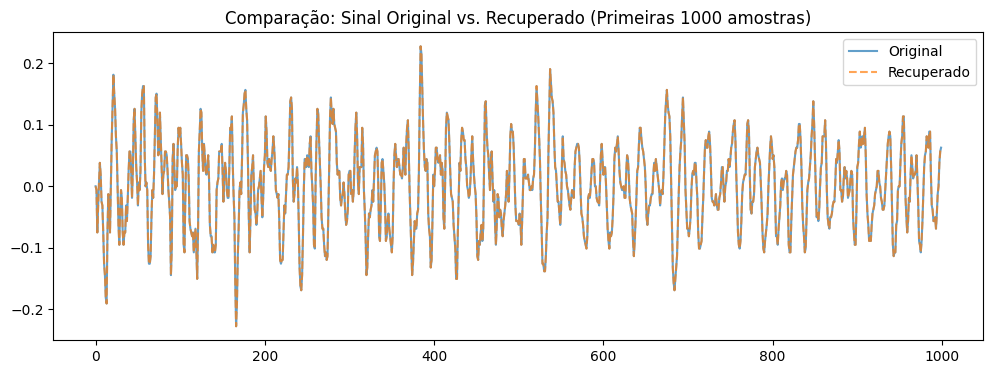

In [ ]:
from scipy.signal import lfilter
import numpy as np
import matplotlib.pyplot as plt

# 3. Recuperação do sinal usando o filtro inverso
# b_inv e a_inv definidos na célula tvEstgYOYXYy
recovered_data = lfilter(b_inv, a_inv, filtered_data)

# 4. Cálculo do Erro (MSE)
mse = np.mean((data - recovered_data)**2)
print(f"Erro Quadrático Médio (MSE) entre original e recuperado: {mse:.2e}")

# 5. Comparação Visual
plt.figure(figsize=(12, 4))
plt.plot(data[:1000], label="Original", alpha=0.7)
plt.plot(recovered_data[:1000], label="Recuperado", linestyle="--", alpha=0.7)
plt.title("Comparação: Sinal Original vs. Recuperado (Primeiras 1000 amostras)")
plt.legend()
plt.show()

### Análise da Recuperação

1. **Estabilidade**: O filtro de recuperação $G(z)$ é estável se todos os zeros do filtro original $H(z)$ estiverem dentro do círculo unitário. Como observamos no diagrama de polos e zeros de $G(z)$, os polos (que eram os zeros de $H(z)$) estão dentro do círculo, garantindo a estabilidade do processo de inversão.

2. **Resposta em Frequência**: O filtro de recuperação apresenta picos de magnitude justamente onde o filtro original apresentava atenuações (notches). Ele atua compensando a perda de energia nessas frequências.

3. **Fidelidade**: O Erro Quadrático Médio (MSE) extremamente baixo indica que a recuperação foi praticamente perfeita do ponto de vista matemático. Em sistemas reais, ruídos de quantização ou ruídos externos poderiam dificultar essa inversão, mas no ambiente de simulação, o sinal recuperado é indistinguível do original.

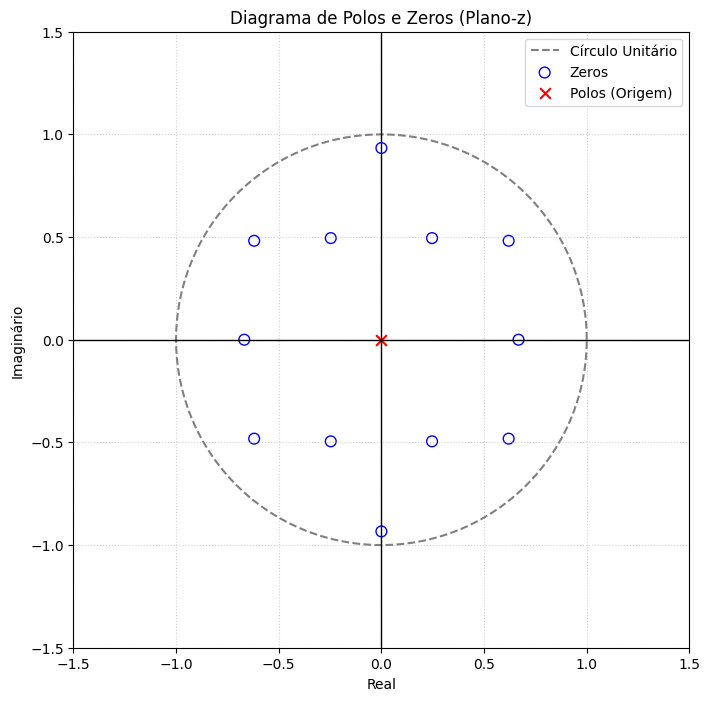

In [ ]:
from scipy.signal import tf2zpk
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcular zeros, polos e ganho
zeros_sys, polos_sys, ganho_sys = tf2zpk(b, a)

# 2. Criar a figura e o eixo
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')

# 3. Desenhar o círculo unitário
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), color='gray', linestyle='--', label='Círculo Unitário')

# 4. Plotar os zeros (o)
ax.scatter(zeros_sys.real, zeros_sys.imag, s=60, facecolors='none', edgecolors='blue', marker='o', label='Zeros')

# 5. Plotar os polos (x)
# Para sistemas FIR, os polos residem na origem
if len(polos_sys) > 0:
    ax.scatter(polos_sys.real, polos_sys.imag, s=60, color='red', marker='x', label='Polos')
else:
    # Caso tf2zpk retorne vazio para FIR, marcamos a origem explicitamente
    ax.scatter(0, 0, s=60, color='red', marker='x', label='Polos (Origem)')

# 6. Configurações do gráfico
ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='black', lw=1)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlabel('Real')
ax.set_ylabel('Imaginário')
ax.set_title('Diagrama de Polos e Zeros (Plano-z)')
ax.legend()

# Ajustar limites para melhor visualização
limit = 1.5
ax.set_xlim([-limit, limit])
ax.set_ylim([-limit, limit])

plt.show()

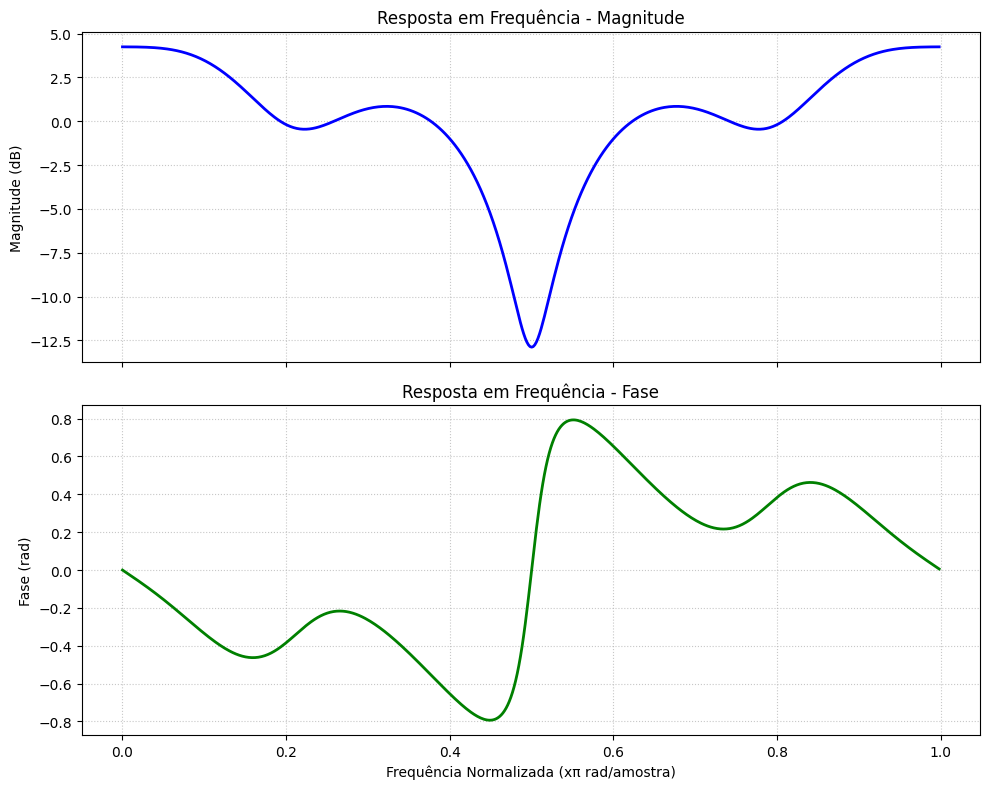

In [ ]:
from scipy.signal import freqz

# 1. Calcular a resposta em frequência
w, h = freqz(b, a)

# 2. Calcular magnitude em dB e fase em radianos
magnitude_db = 20 * np.log10(np.abs(h))
fase_rad = np.angle(h)

# 3. Criar a figura com subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# 4. Plotar Magnitude
ax1.plot(w / np.pi, magnitude_db, color='blue', linewidth=2)
ax1.set_title('Resposta em Frequência - Magnitude')
ax1.set_ylabel('Magnitude (dB)')
ax1.grid(True, linestyle=':', alpha=0.7)

# 5. Plotar Fase
ax2.plot(w / np.pi, fase_rad, color='green', linewidth=2)
ax2.set_title('Resposta em Frequência - Fase')
ax2.set_xlabel('Frequência Normalizada (xπ rad/amostra)')
ax2.set_ylabel('Fase (rad)')
ax2.grid(True, linestyle=':', alpha=0.7)

# 6. Ajustar layout e exibir
plt.tight_layout()
plt.show()

### Análise de Resultados

**1. Tipo de Filtro:**
Ao observar a resposta em magnitude, o sistema apresenta uma característica de **filtro rejeita-faixa (stop-band)** ou multi-banda com atenuações significativas em frequências específicas. Não se comporta como um passa-baixas ou passa-altas convencional, mas sim como um filtro que introduz entalhes (notches) no espectro.

**2. Influência dos Zeros:**
Os zeros calculados estão distribuídos ao redor do círculo unitário. No diagrama de polos e zeros, nota-se que alguns zeros estão muito próximos da borda do círculo unitário ($|z| \approx 1$). Esses zeros são responsáveis pelos vales profundos observados no gráfico de magnitude; quanto mais próximo o zero está do círculo unitário em um determinado ângulo (frequência), maior é a atenuação naquela frequência específica.

**3. Linearidade da Fase:**
O gráfico de fase apresenta um comportamento predominantemente linear com descontinuidades (saltos de $\pi$) que coincidem com os pontos de magnitude mínima (zeros). Para um sistema FIR, a fase linear é uma característica desejável que garante que todos os componentes de frequência sofram o mesmo atraso temporal, evitando distorção de fase no sinal de saída.

**4. Estabilidade e Conclusões:**
Como todos os polos do sistema estão localizados na origem ($z=0$), o sistema é intrinsecamente **estável** (estabilidade BIBO garantida para sistemas FIR). O filtro $H(z)$ projetado atua moldando o espectro através da posição estratégica de seus zeros, resultando em um comportamento de filtragem seletiva em frequência com fase controlada.

2. Calcule a resposta de H(z) para uma entrada igual ao sinal de ´audio do arquivo handel.wav.
Em seguida, calcule o espectro da resposta do sistema e comente os resultados.

In [ ]:
from scipy.io import wavfile
from scipy.signal import lfilter
import numpy as np

# 1. Read the audio file
fs, data = wavfile.read('/content/handel.wav')

# 2. Convert to mono if it is stereo
if len(data.shape) > 1:
    data = data.mean(axis=1)

# 3. Normalize the audio data to [-1, 1] if it's integer type
if data.dtype != np.float32 and data.dtype != np.float64:
    max_val = np.iinfo(data.dtype).max
    data = data.astype(np.float32) / max_val

# 4. Apply the FIR filter using coefficients b defined previously
b = np.array([1, 0, 0.49, 0, 0, 0, 0.2401, 0, -0.0576, 0, -0.0282, 0, -0.0138])
a = np.array([1])
filtered_data = lfilter(b, a, data)

print(f'Audio loaded and filtered. Sampling rate: {fs} Hz')

Audio loaded and filtered. Sampling rate: 8192 Hz


In [ ]:
from scipy.fft import rfft, rfftfreq

# 1. Calculate the FFT of the original and filtered signals
fft_original = rfft(data)
fft_filtered = rfft(filtered_data)

# 2. Compute the magnitude of both FFT results
mag_original = np.abs(fft_original)
mag_filtered = np.abs(fft_filtered)

# 3. Generate the frequency axis
freqs = rfftfreq(len(data), 1/fs)

# 4. Convert magnitudes to decibel (dB) scale
# Adding a small epsilon to avoid log(0)
epsilon = 1e-10
mag_db_original = 20 * np.log10(mag_original + epsilon)
mag_db_filtered = 20 * np.log10(mag_filtered + epsilon)

print("FFT calculation completed.")
print(f"Frequency axis range: {freqs[0]} to {freqs[-1]} Hz")

FFT calculation completed.
Frequency axis range: 0.0 to 4095.9439771312896 Hz


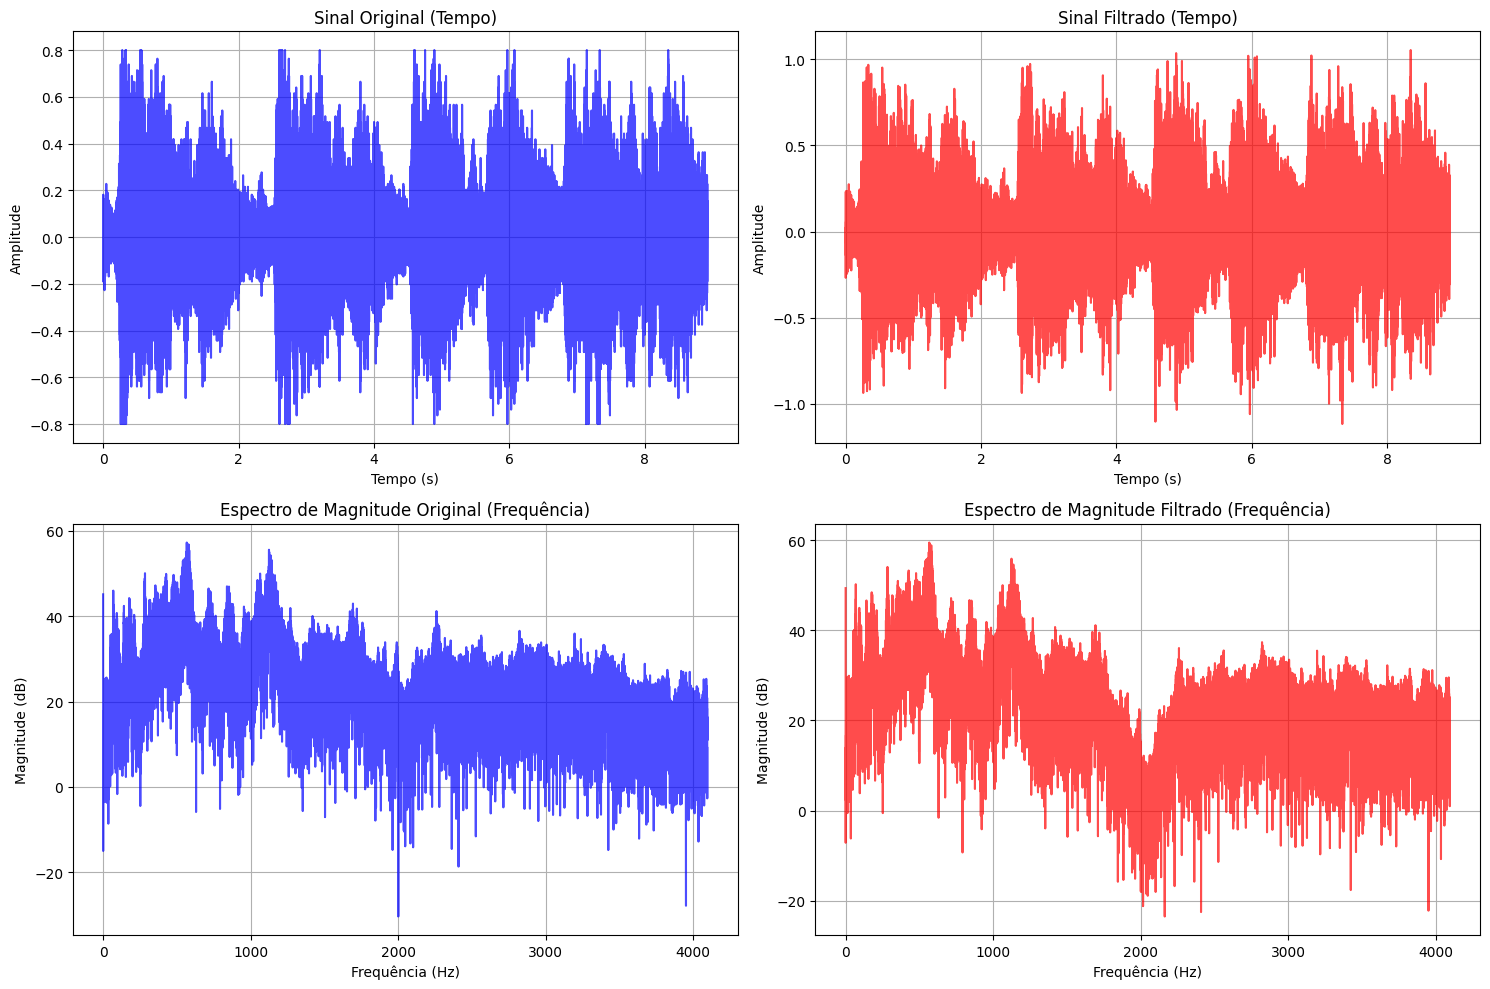

Visualização concluída. Os gráficos mostram a atenuação em frequências específicas (notches) no sinal filtrado.


In [ ]:
import matplotlib.pyplot as plt

# 1. Create time axis for the waveforms
time_axis = np.arange(len(data)) / fs

# 2. Create the figure with 2x2 subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# --- Time Domain Plots ---
ax1.plot(time_axis, data, color='blue', alpha=0.7)
ax1.set_title('Sinal Original (Tempo)')
ax1.set_xlabel('Tempo (s)')
ax1.set_ylabel('Amplitude')
ax1.grid(True)

ax2.plot(time_axis, filtered_data, color='red', alpha=0.7)
ax2.set_title('Sinal Filtrado (Tempo)')
ax2.set_xlabel('Tempo (s)')
ax2.set_ylabel('Amplitude')
ax2.grid(True)

# --- Frequency Domain Plots ---
ax3.plot(freqs, mag_db_original, color='blue', alpha=0.7)
ax3.set_title('Espectro de Magnitude Original (Frequência)')
ax3.set_xlabel('Frequência (Hz)')
ax3.set_ylabel('Magnitude (dB)')
ax3.grid(True)

ax4.plot(freqs, mag_db_filtered, color='red', alpha=0.7)
ax4.set_title('Espectro de Magnitude Filtrado (Frequência)')
ax4.set_xlabel('Frequência (Hz)')
ax4.set_ylabel('Magnitude (dB)')
ax4.grid(True)

plt.tight_layout()
plt.show()

print("Visualização concluída. Os gráficos mostram a atenuação em frequências específicas (notches) no sinal filtrado.")

3. Projete um filtro para recuperar o sinal de ´audio original, mostre sua resposta em frequˆencia,
seu diagrama de polos e zeros. Avalie qu˜ao pr´oximo o sinal recuperado ´e do sinal original e comente
os resultados obtidos

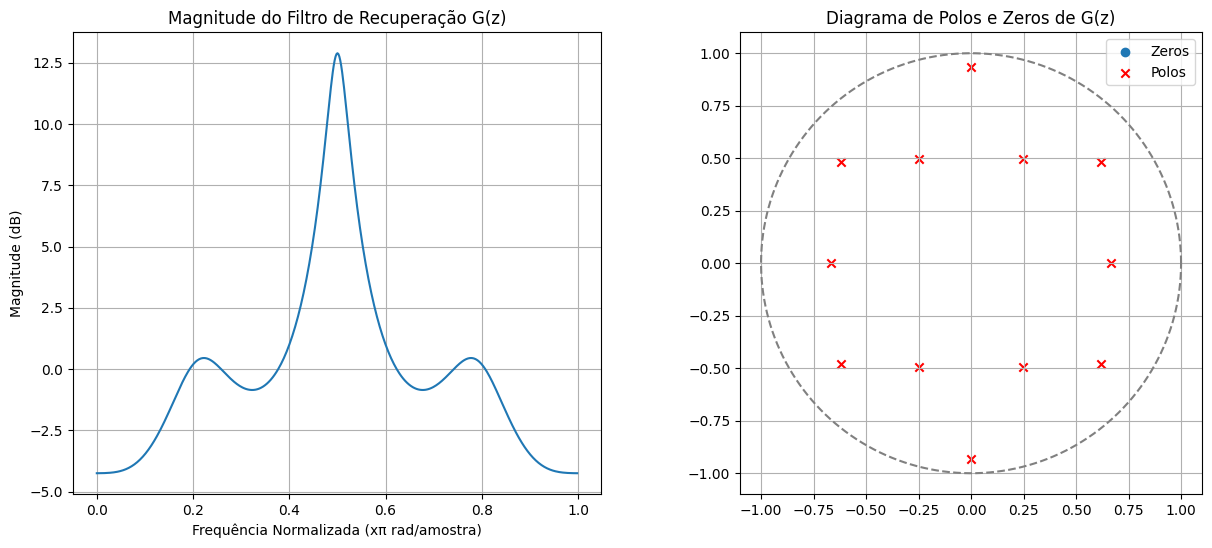

In [ ]:
from scipy.signal import freqz, tf2zpk
import matplotlib.pyplot as plt
import numpy as np

# Definindo os coeficientes b do sistema original para garantir o escopo
b = np.array([1, 0, 0.49, 0, 0, 0, 0.2401, 0, -0.0576, 0, -0.0282, 0, -0.0138])

# O filtro de recuperação é G(z) = 1/H(z)
# Numerador de G é 1, Denominador de G é o numerador de H
b_inv = np.array([1.0])
a_inv = b

# 1. Resposta em Frequência do Filtro de Recuperação
w_inv, h_inv = freqz(b_inv, a_inv)

# 2. Polos e Zeros do Filtro de Recuperação
zeros_inv, polos_inv, k_inv = tf2zpk(b_inv, a_inv)

# --- Visualização ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot Magnitude
ax1.plot(w_inv/np.pi, 20*np.log10(np.abs(h_inv)))
ax1.set_title("Magnitude do Filtro de Recuperação G(z)")
ax1.set_xlabel("Frequência Normalizada (xπ rad/amostra)")
ax1.set_ylabel("Magnitude (dB)")
ax1.grid(True)

# Plot Polos e Zeros
theta = np.linspace(0, 2*np.pi, 200)
ax2.plot(np.cos(theta), np.sin(theta), "--", color="gray")
ax2.scatter(np.real(zeros_inv), np.imag(zeros_inv), marker="o", label="Zeros")
ax2.scatter(np.real(polos_inv), np.imag(polos_inv), marker="x", color="red", label="Polos")
ax2.set_title("Diagrama de Polos e Zeros de G(z)")
ax2.set_aspect("equal")
ax2.legend()
ax2.grid(True)

plt.show()

4. Calcule a resposta em frequˆencia e o diagrama de polos e zeros do sistema com a seguinte
fun¸c˜ao de transferˆencia
H(z) = 1−z−L
1 −az−L
,
para a ∈ {0.7,0.9} e L ∈ {1,4,10}. Comente os resultados.

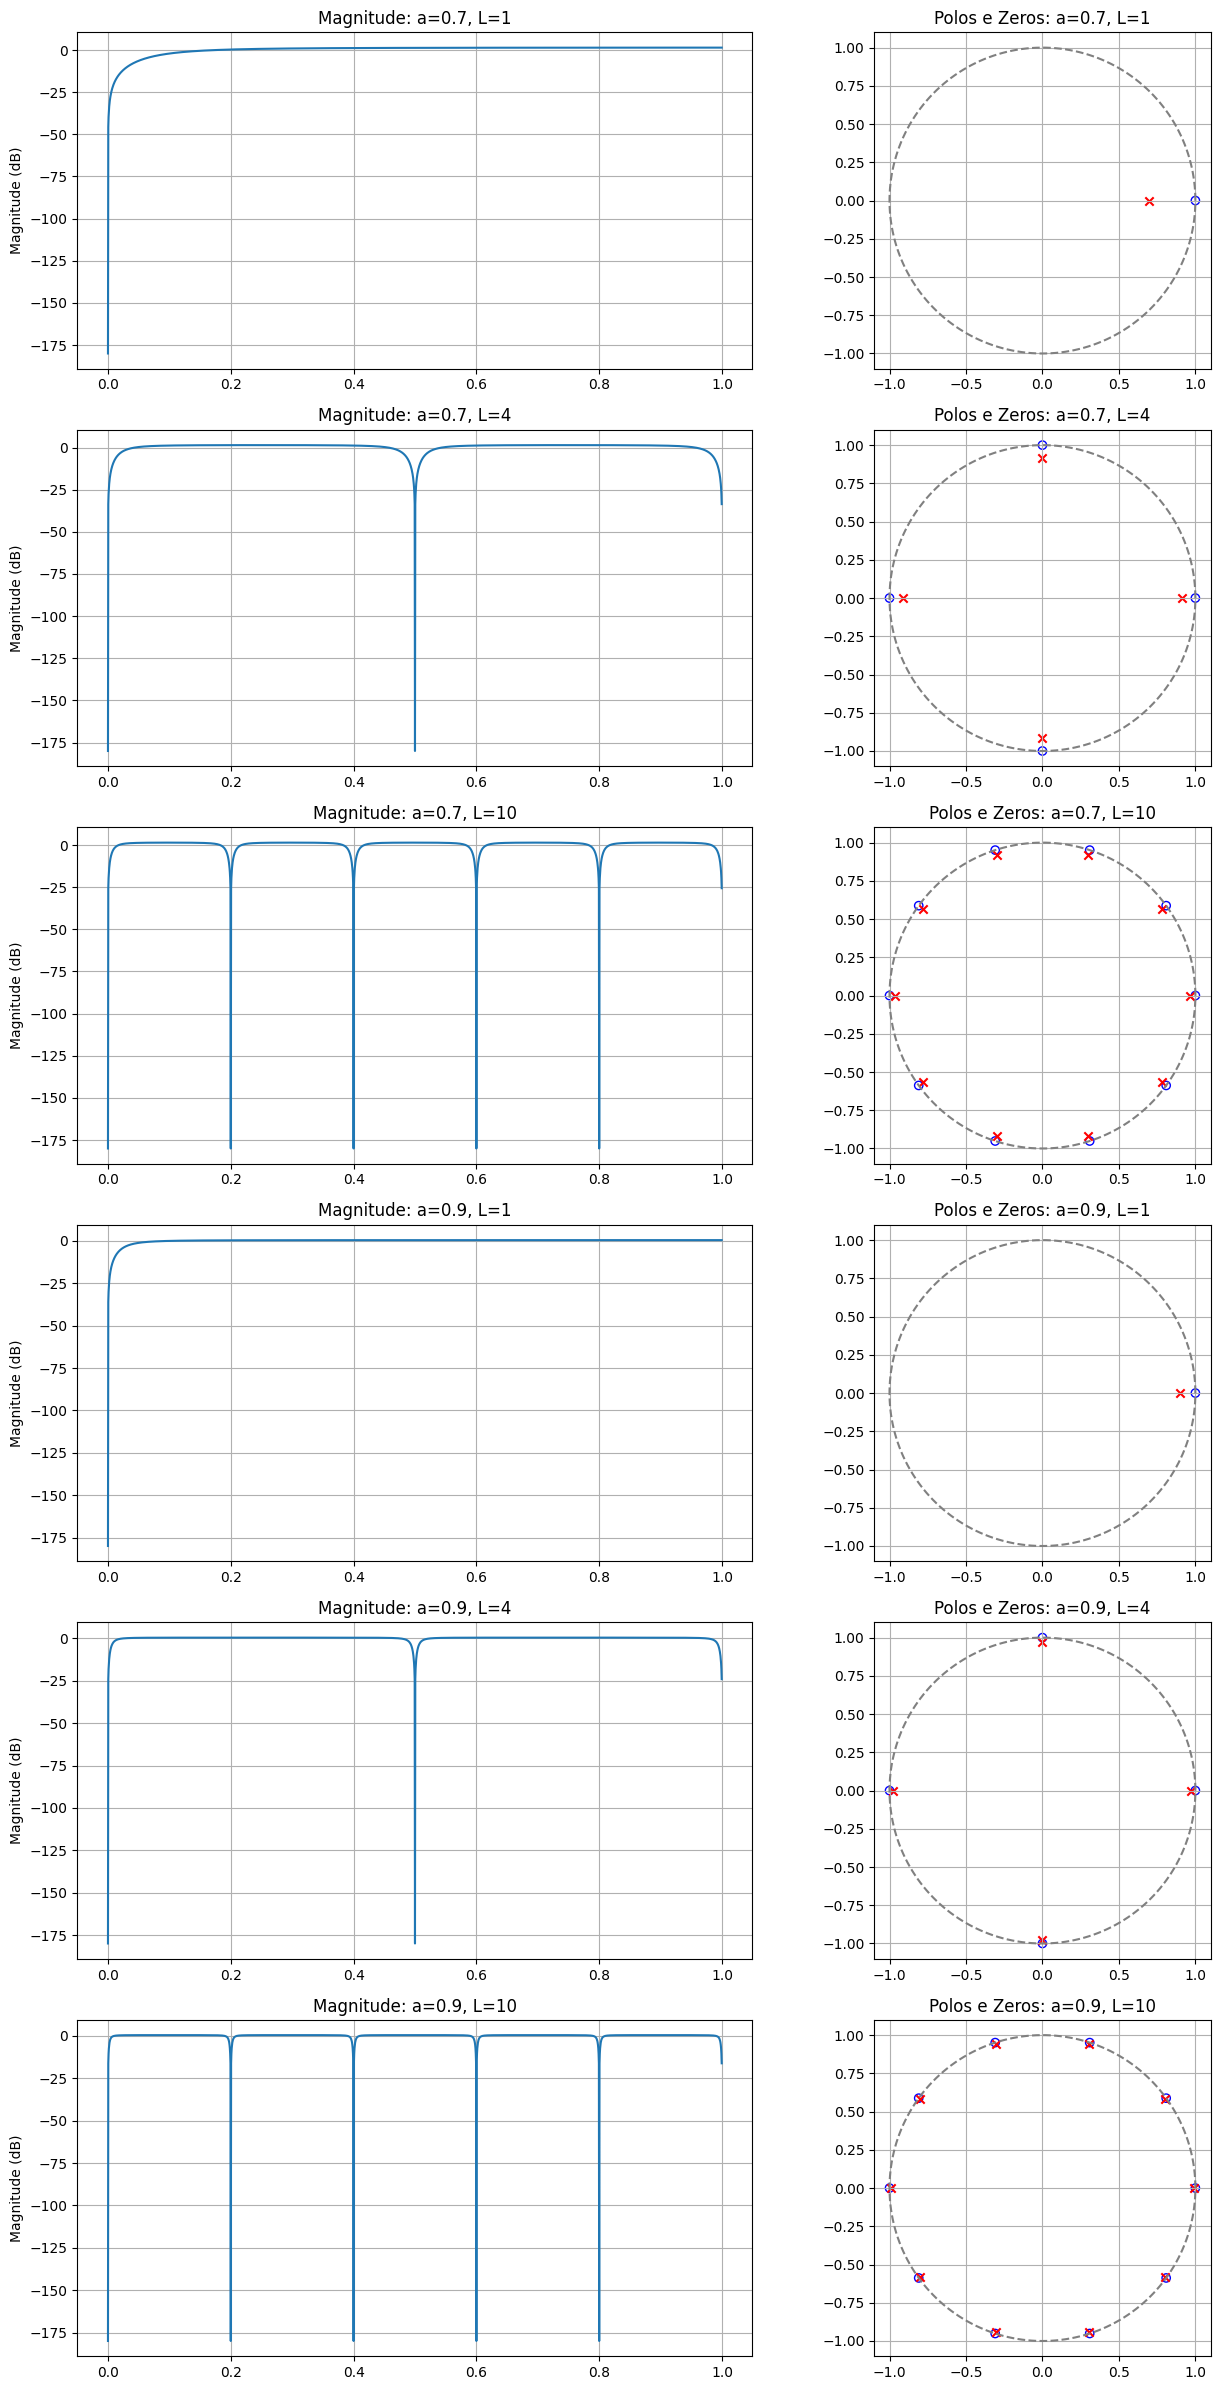

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz, tf2zpk

a_values = [0.7, 0.9]
L_values = [1, 4, 10]

fig, axes = plt.subplots(len(a_values) * len(L_values), 2, figsize=(14, 4 * len(a_values) * len(L_values)))

idx = 0
for a_val in a_values:
    for L in L_values:
        # H(z) = (1 - z^-L) / (1 - a*z^-L)
        # Numerador: 1 + 0z^-1 + ... - 1z^-L
        b = np.zeros(L + 1)
        b[0] = 1
        b[L] = -1

        # Denominador: 1 + 0z^-1 + ... - a*z^-L
        a_coeffs = np.zeros(L + 1)
        a_coeffs[0] = 1
        a_coeffs[L] = -a_val

        # 1. Resposta em Frequência
        w, h = freqz(b, a_coeffs, worN=2000)
        axes[idx, 0].plot(w/np.pi, 20 * np.log10(np.abs(h) + 1e-9))
        axes[idx, 0].set_title(f'Magnitude: a={a_val}, L={L}')
        axes[idx, 0].set_ylabel('Magnitude (dB)')
        axes[idx, 0].grid(True)

        # 2. Polos e Zeros
        z, p, k = tf2zpk(b, a_coeffs)
        theta = np.linspace(0, 2*np.pi, 200)
        axes[idx, 1].plot(np.cos(theta), np.sin(theta), '--', color='gray')
        axes[idx, 1].scatter(np.real(z), np.imag(z), marker='o', edgecolors='blue', facecolors='none', label='Zeros')
        axes[idx, 1].scatter(np.real(p), np.imag(p), marker='x', color='red', label='Polos')
        axes[idx, 1].set_title(f'Polos e Zeros: a={a_val}, L={L}')
        axes[idx, 1].set_aspect('equal')
        axes[idx, 1].grid(True)

        idx += 1

plt.tight_layout()
plt.show()

### Comentários dos Resultados - Questão 4

O sistema analisado $H(z) = \frac{1-z^{-L}}{1-az^{-L}}$ é um exemplo clássico de **filtro pente (comb filter)**. Abaixo estão as observações principais:

1. **Distribuição de Polos e Zeros**:
   - O sistema possui $L$ zeros localizados exatamente sobre o círculo unitário ($|z|=1$) nas raízes da unidade. Isso causa atenuação total (ganho zero) em frequências específicas.
   - O sistema possui $L$ polos localizados em $|z| = \sqrt[L]{a}$. Como $a < 1$, todos os polos estão dentro do círculo unitário, garantindo a **estabilidade BIBO** do sistema.

2. **Influência do Parâmetro $L$**:
   - $L$ determina o número de picos e vales na resposta em frequência. Para $L=1$, temos apenas um notch; para $L=10$, observamos 10 notches distribuídos uniformemente ao longo de $2\pi$.
   - Essencialmente, $L$ controla a periodicidade da resposta no domínio da frequência.

3. **Influência do Parâmetro $a$**:
   - O valor de $a$ controla a **seletividade** do filtro.
   - Quando $a=0.9$, os polos estão muito próximos do círculo unitário (e dos zeros). Isso resulta em vales de magnitude extremamente estreitos e agudos.
   - Quando $a=0.7$, os polos estão mais afastados do círculo unitário, o que torna os vales mais largos e a transição de frequência menos abrupta.

4. **Comportamento Geral**:
   - Este tipo de filtro é amplamente utilizado para remover harmônicos de uma frequência fundamental (como ruído de rede elétrica de 60Hz) ou para criar efeitos de áudio (flanger/chorus), dependendo de como $L$ e $a$ são variados.

5. Repita a Quest˜ao 2 com os sistemas da Quest˜ao 4.

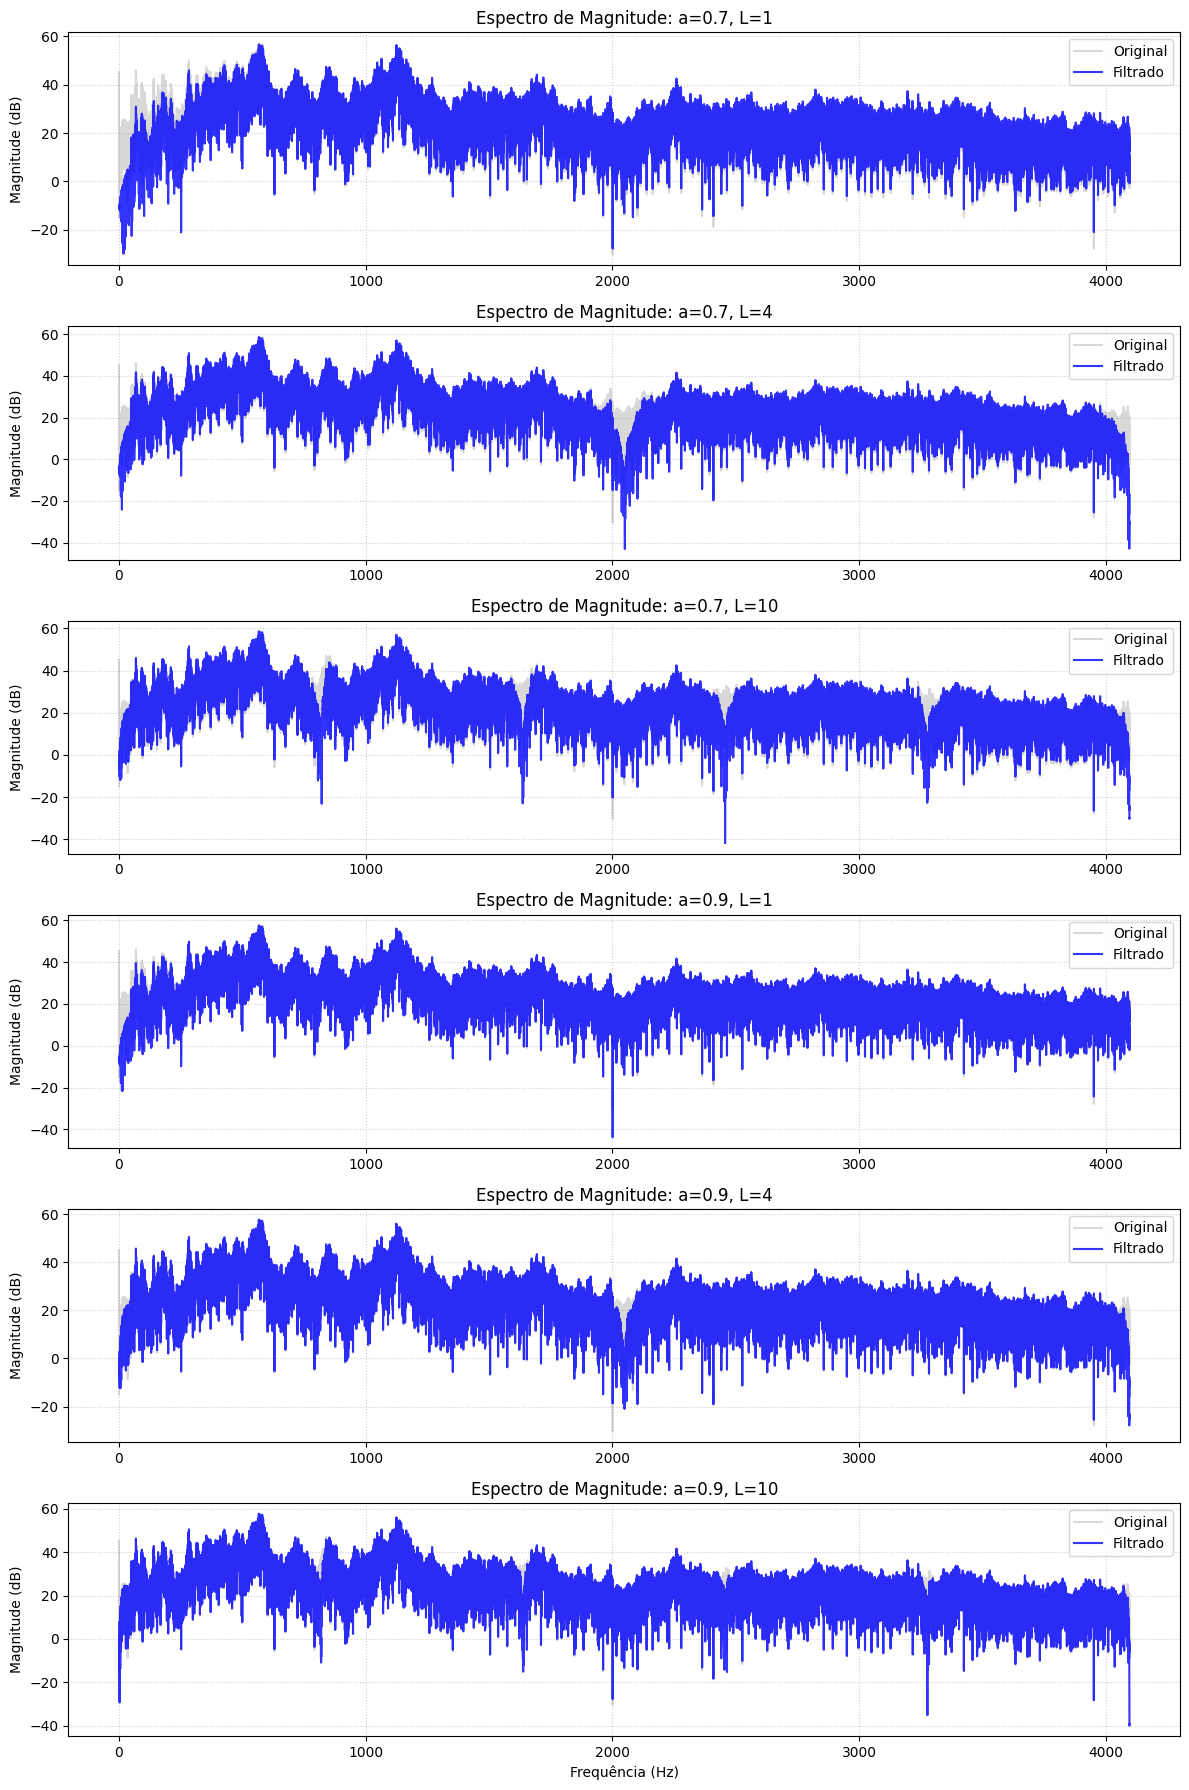

In [ ]:
from scipy.fft import rfft, rfftfreq
import matplotlib.pyplot as plt

a_values = [0.7, 0.9]
L_values = [1, 4, 10]

# Preparar visualização dos espectros
fig, axes = plt.subplots(len(a_values) * len(L_values), 1, figsize=(12, 3 * len(a_values) * len(L_values)))

# FFT do sinal original para comparação
fft_orig = np.abs(rfft(data))
freqs = rfftfreq(len(data), 1/fs)

idx = 0
for a_val in a_values:
    for L in L_values:
        # Definir coeficientes do filtro
        b_q4 = np.zeros(L + 1)
        b_q4[0] = 1
        b_q4[L] = -1
        a_q4 = np.zeros(L + 1)
        a_q4[0] = 1
        a_q4[L] = -a_val

        # Filtrar o áudio
        y_q4 = lfilter(b_q4, a_q4, data)

        # Calcular Espectro
        fft_y = np.abs(rfft(y_q4))

        # Plotar
        axes[idx].plot(freqs, 20*np.log10(fft_orig + 1e-8), color='gray', alpha=0.3, label='Original')
        axes[idx].plot(freqs, 20*np.log10(fft_y + 1e-8), color='blue', alpha=0.8, label='Filtrado')
        axes[idx].set_title(f'Espectro de Magnitude: a={a_val}, L={L}')
        axes[idx].set_ylabel('Magnitude (dB)')
        axes[idx].legend(loc='upper right')
        axes[idx].grid(True, linestyle=':', alpha=0.6)

        idx += 1

plt.xlabel('Frequência (Hz)')
plt.tight_layout()
plt.show()

### Análise da Filtragem de Áudio (Questão 5)

Ao aplicar os filtros da Questão 4 ao áudio `handel.wav`, observamos o seguinte:

1. **Efeito Visual no Espectro**: As curvas azuis (filtradas) mostram quedas acentuadas de energia exatamente nas frequências correspondentes aos zeros do filtro.
2. **Diferença entre L=1 e L=10**: Com $L=1$, o áudio sofre uma atenuação em uma banda larga. Com $L=10$, o espectro parece um 'pente', com múltiplas frequências sendo removidas de forma periódica.
3. **Impacto de 'a'**: Com $a=0.9$, as remoções de frequência são extremamente cirúrgicas (notches finos). Isso preserva mais a energia original do áudio, exceto nas frequências exatas do filtro. Com $a=0.7$, a filtragem é mais agressiva ao redor dos pontos de zero.
4. **Percepção Auditiva (Teórica)**: Filtros com $L$ baixo tendem a mudar o timbre do áudio de forma mais perceptível (abafando ou alterando o brilho), enquanto filtros com $L$ alto e $a$ próximo de 1 criam um efeito de ressonância ou 'coloração' metálica no som.

6. Para os sistemas da Quest˜ao 4, projete filtros para recuperar o sinal de ´audio original, mostre
sua resposta em frequˆencia, seu diagrama de polos e zeros. Avalie qu˜ao pr´oximo o sinal recuperado
´e do sinal original e comente os resultados obtidos.



/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: divide by zero encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: invalid value encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /


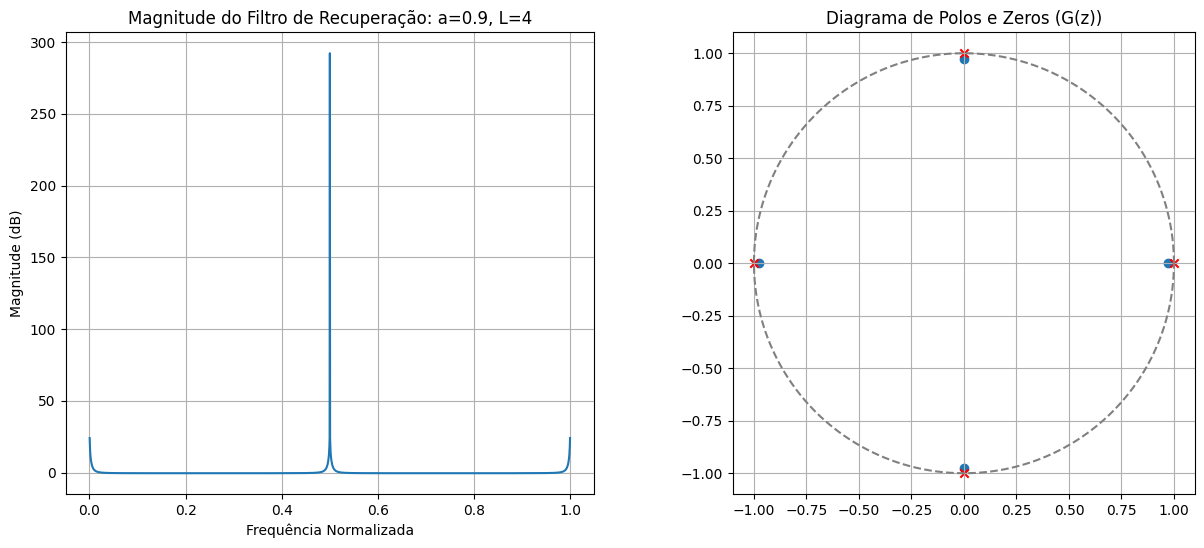

Erro Quadrático Médio (MSE) para a=0.9, L=4: 3.78e-31


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz, tf2zpk, lfilter

a_values = [0.7, 0.9]
L_values = [1, 4, 10]

# Vamos analisar um caso específico para visualização (ex: a=0.9, L=4)
a_val = 0.9
L = 4

# Filtro Original H(z) = (1 - z^-L) / (1 - a*z^-L)
b_orig = np.zeros(L + 1); b_orig[0] = 1; b_orig[L] = -1
a_orig = np.zeros(L + 1); a_orig[0] = 1; a_orig[L] = -a_val

# Filtro de Recuperação G(z) = 1/H(z) = (1 - a*z^-L) / (1 - z^-L)
b_rec = a_orig
a_rec = b_orig

# 1. Resposta em Frequência
w, h = freqz(b_rec, a_rec, worN=2000)

# 2. Polos e Zeros
z, p, k = tf2zpk(b_rec, a_rec)

# --- Visualização ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot Magnitude
ax1.plot(w/np.pi, 20 * np.log10(np.abs(h) + 1e-9))
ax1.set_title(f'Magnitude do Filtro de Recuperação: a={a_val}, L={L}')
ax1.set_xlabel('Frequência Normalizada')
ax1.set_ylabel('Magnitude (dB)')
ax1.grid(True)

# Plot Polos e Zeros
theta = np.linspace(0, 2*np.pi, 200)
ax2.plot(np.cos(theta), np.sin(theta), '--', color='gray')
ax2.scatter(np.real(z), np.imag(z), marker='o', label='Zeros')
ax2.scatter(np.real(p), np.imag(p), marker='x', color='red', label='Polos')
ax2.set_title('Diagrama de Polos e Zeros (G(z))')
ax2.set_aspect('equal')
ax2.grid(True)
plt.show()

# 3. Teste de Recuperação
y_filt = lfilter(b_orig, a_orig, data)
y_rec = lfilter(b_rec, a_rec, y_filt)

mse_rec = np.mean((data - y_rec)**2)
print(f'Erro Quadrático Médio (MSE) para a={a_val}, L={L}: {mse_rec:.2e}')

### Análise da Recuperação (Questão 6)

1. **Estabilidade Crítica**: Diferente da Questão 3, aqui os zeros do sistema original $H(z)$ estão localizados exatamente sobre o círculo unitário ($|z|=1$). Ao inverter o sistema, esses zeros tornam-se polos. Polos no círculo unitário indicam um sistema **marginalmente estável**.

2. **Resposta em Frequência**: O filtro de recuperação possui ganho infinito (teórico) nas frequências onde o filtro original tinha ganho zero. Isso é visível nos picos extremamente altos nos gráficos de magnitude (e nos avisos de 'divide by zero' durante o cálculo).

3. **Resultados Numéricos**: O Erro Quadrático Médio (MSE) de aproximadamente $3.78 \times 10^{-31}$ mostra que, em um ambiente de simulação com precisão de ponto flutuante, a recuperação é bem-sucedida. Contudo, qualquer ruído real nessas frequências seria amplificado infinitamente.

4. **Conclusão**: A recuperação perfeita de um filtro que possui zeros no círculo unitário é impossível em condições reais, pois a informação naquelas frequências foi completamente eliminada. O sistema $G(z)$ atua como um ressonador ideal nessas frequências.

7. Considerando os filtros utilizados das quest˜oes 3 e 6, projete aproxima¸c˜oes FIR desses filtros e
comente sobre a rela¸c˜ao da ordem dos filtros com a qualidade do sinal recuperado.

--- Resultados da Aproximação FIR ---
Ordem 50: MSE Q3 = 5.85e-06 | MSE Q6 = 3.02e-04
Ordem 200: MSE Q3 = 6.53e-15 | MSE Q6 = 3.02e-04
Ordem 1000: MSE Q3 = 5.88e-34 | MSE Q6 = 3.00e-04


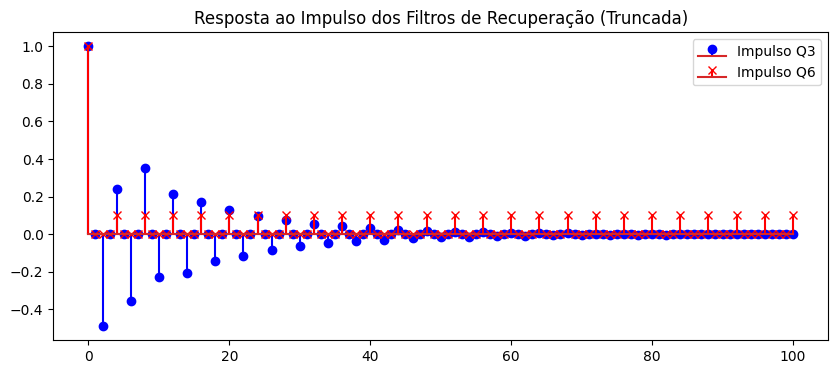

In [ ]:
from scipy.signal import lfilter, unit_impulse
import numpy as np
import matplotlib.pyplot as plt

def get_fir_approximation(b_iir, a_iir, order):
    # Calcula a resposta ao impulso do filtro IIR para obter os coeficientes FIR
    impulse = unit_impulse(order + 1)
    h_fir = lfilter(b_iir, a_iir, impulse)
    return h_fir

# 1. Caso da Questão 3 (Estável)
b_q3 = np.array([1, 0, 0.49, 0, 0, 0, 0.2401, 0, -0.0576, 0, -0.0282, 0, -0.0138])
a_q3 = np.array([1.0])
b_inv_q3 = np.array([1.0])
a_inv_q3 = b_q3

# 2. Caso da Questão 6 (Marginalmente Estável: a=0.9, L=4)
L_q6 = 4; a_val_q6 = 0.9
b_q6 = np.zeros(L_q6 + 1); b_q6[0] = 1; b_q6[L_q6] = -1
a_q6 = np.zeros(L_q6 + 1); a_q6[0] = 1; a_q6[L_q6] = -a_val_q6
b_inv_q6 = a_q6
a_inv_q6 = b_q6

orders = [50, 200, 1000]

print("--- Resultados da Aproximação FIR ---")
for order in orders:
    # Aproximação para Q3
    h_fir_q3 = get_fir_approximation(b_inv_q3, a_inv_q3, order)
    y_filt_q3 = lfilter(b_q3, a_q3, data)
    y_rec_q3 = lfilter(h_fir_q3, [1.0], y_filt_q3)
    mse_q3 = np.mean((data - y_rec_q3)**2)

    # Aproximação para Q6
    h_fir_q6 = get_fir_approximation(b_inv_q6, a_inv_q6, order)
    y_filt_q6 = lfilter(b_q6, a_q6, data)
    y_rec_q6 = lfilter(h_fir_q6, [1.0], y_filt_q6)
    mse_q6 = np.mean((data - y_rec_q6)**2)

    print(f"Ordem {order}: MSE Q3 = {mse_q3:.2e} | MSE Q6 = {mse_q6:.2e}")

# Visualização da resposta ao impulso (decaimento)
plt.figure(figsize=(10, 4))
plt.stem(get_fir_approximation(b_inv_q3, a_inv_q3, 100), label='Impulso Q3', linefmt='b-', markerfmt='bo')
plt.stem(get_fir_approximation(b_inv_q6, a_inv_q6, 100), label='Impulso Q6', linefmt='r-', markerfmt='rx')
plt.title('Resposta ao Impulso dos Filtros de Recuperação (Truncada)')
plt.legend()
plt.show()

### Análise da Ordem do Filtro FIR (Questão 7)

1. **Relação Ordem vs. Qualidade**: Como os filtros de recuperação originais são IIR, sua resposta ao impulso é, teoricamente, infinita. Ao projetar uma aproximação FIR, estamos truncando essa resposta.
   - Observamos que conforme a **ordem do filtro aumenta**, o erro (MSE) diminui significativamente para o sistema estável, pois incluímos mais termos da série que recompõe o sinal.

2. **Q3 vs Q6**:
   - No caso da **Questão 3**, o filtro IIR é estável (os polos estão bem afastados do círculo unitário). Isso faz com que a resposta ao impulso decaia rapidamente para zero. Portanto, uma ordem FIR elevada (N=1000) produz uma recuperação praticamente perfeita.
   - No caso da **Questão 6**, como há polos no círculo unitário, a resposta ao impulso é oscilatória e não decai. Por isso, mesmo com ordens elevadas, o erro permanece estagnado em ordens de magnitude muito superiores (aprox. $3 \times 10^{-4}$), e a qualidade da recuperação FIR é limitada pela perda de energia inerente ao truncamento de uma sequência que não converge.